# The Physical Basis for Ocean Color Products

## Motivation

Ocean color remote sensing uses visible and near-infrared measurements to infer properties of the upper ocean. The most common product is chlorophyll-a concentration, which is often used as an indicator of phytoplankton biomass.

Ocean color observations are useful because phytoplankton form the base of many marine food webs and play an important role in the global carbon cycle. However, ocean color products require careful interpretation: a satellite does not directly measure chlorophyll-a. Instead, it measures radiance leaving the ocean-atmosphere system, and algorithms are used to convert those observations into geophysical products.

### Some Key Questions for Consideration

- What happens to sunlight when it reaches the ocean surface?
- How do absorption and scattering determine the color of the ocean?
- Why is chlorophyll-a visible to satellites?
- What are the main limitations of ocean color observations?

**Modules for this notebook**

In this notebook, we'll take a look at a few plots to help our understanding. Here, we'll import some Python modules to aid in our plotting.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap, LogNorm

In [2]:
water_color = "#1f77b4"
chla_color = "#2ca02c"

blue_green_cmap = LinearSegmentedColormap.from_list(
    "blue_green",
    [water_color, chla_color]
)
norm = LogNorm(vmin=0.001, vmax=100)

## Electromagnetic Radiation at the Ocean Surface

Visible light can penetrate the ocean surface. Once it reaches the ocean, several things can happen:

1. Some light is **directly reflected** from the surface.
2. Some light is **transmitted** into the water column.
3. Within the water column, light can be **absorbed** or **scattered**.
4. A small fraction of scattered light exits the ocean and travels upward toward the satellite.

The upward signal that exits the ocean is called **water-leaving radiance**. Ocean color algorithms are designed to isolate this water-leaving signal from other contributions such as atmospheric scattering, surface reflection, and sunglint.

### Sunglint and Surface Reflection

Sunglint occurs when sunlight reflects off the ocean surface toward the satellite sensor. Glint can overwhelm the water-leaving radiance signal, especially when the Sun-sensor geometry is unfavorable or the ocean surface is rough.

Because ocean color retrievals rely on a small signal leaving the water column, sunglint and clouds are commonly masked from higher-level ocean color products.

### Absorption by Water

Liquid water absorbs long visible wavelengths more strongly than short visible wavelengths. Red light is absorbed efficiently, while blue light penetrates farther into clear water. Infrared radiation is absorbed extremely close to the surface, which is why infrared observations are useful for sea surface temperature but not for observing subsurface ocean color (see next section).

The figure below shows the absorption of pure water in both linear and logarithmic scales:

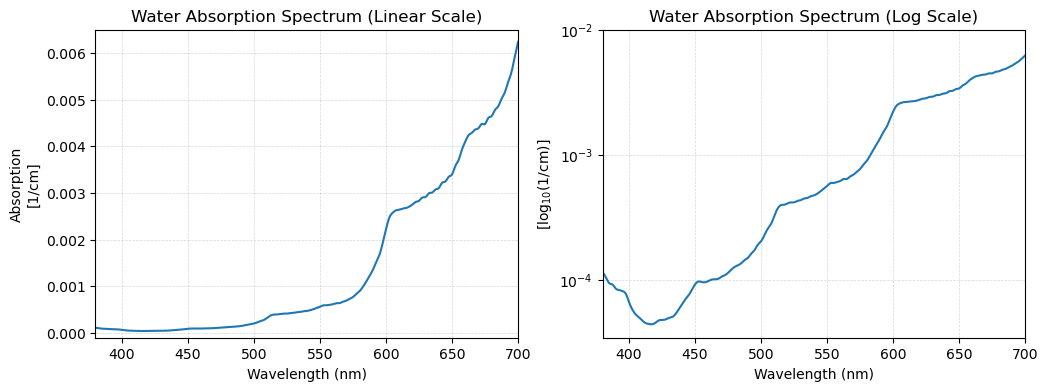

In [3]:
# read in the spectrum
water_spectrum = np.genfromtxt('../data/ocean_color/water_absorption_spectrum.csv',delimiter=',')

# make a plot
fig = plt.figure(figsize=(12,4))

# linear scale
plt.subplot(1,2,1)
plt.plot(water_spectrum[:,0], water_spectrum[:,1], color=water_color)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Absorption\n[1/cm]')
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)
plt.title('Water Absorption Spectrum (Linear Scale)')
plt.gca().set_xlim([380,700])
plt.gca().set_ylim([-0.0001,0.0065])

# log scale
plt.subplot(1,2,2)
plt.plot(water_spectrum[:,0], np.log10(water_spectrum[:,1]), color=water_color)
plt.xlabel('Wavelength (nm)')
plt.ylabel('[log$_{10}$(1/cm)]')
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)
plt.title('Water Absorption Spectrum (Log Scale)')
plt.gca().set_xlim([380,700])
plt.gca().set_yticks([-4, -3, -2], ['10$^{-4}$', '10$^{-3}$', '10$^{-2}$'])

plt.show()

As we can see in the figure above, light at longer wavelengths (e.g. red) absorbs much stronger than wavelengths in the blue-green component of the spectrum. This turns out to be quite advantageous for examining green-colored 

### Scattering by Water

The color observed by a satellite also depends on scattering, which redirects photons. Some scattered photons eventually leave the ocean and can be observed by a satellite.

In clear open-ocean water, blue wavelengths are scattered efficiently. This scattering is similar to the Rayleigh scattering in the atmosphere discussed in the Fundamentals section and has an inverse 4$^{th}$ root dependence with wavelength. Like the sky, this scattering is the same reasion that the ocean appears blue. More information about this scattering can be found in [Zhang et al 2009](https://doi.org/10.1364/OE.17.001671).

The scattering can be visualized with an idealized curve as shown below:

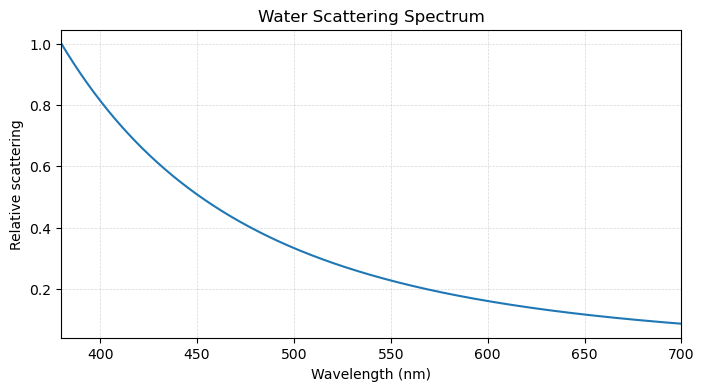

In [4]:
wavelength = water_spectrum[:,0]
# water_scattering = (wavelength / 380) ** -4
# water_scattering = water_scattering / water_scattering.max()

water_scattering = (550 / wavelength) ** 4
water_scattering = water_scattering / water_scattering.max()

plt.figure(figsize=(8,4))
plt.plot(wavelength, water_scattering, color=water_color)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Relative scattering')
plt.title('Water Scattering Spectrum')
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)
plt.gca().set_xlim([380,700])
plt.show()

## Remote-Sensing Reflectance

A common quantity in ocean color is **remote-sensing reflectance**, often written as:

$$R_{rs}(\lambda) = \frac{L_w(\lambda)}{E_d(\lambda)}$$

where:

- $R_{rs}(\lambda)$ is remote-sensing reflectance at wavelength $\lambda$.
- $L_w(\lambda)$ is water-leaving radiance.
- $E_d(\lambda)$ is downwelling irradiance.

Empirical chlorophyll-a algorithms often use ratios of blue and green reflectance because chlorophyll-a changes the relative amount of blue and green light leaving the ocean.

We can compute this for water as follows:

In [5]:
# gather absorption from the water spectrum
absorption = water_spectrum[:,1]

# Pure-water-like backscatter
scattering_factor = 5e-5
scattering = scattering_factor * water_scattering

# compute remote sensing reflectance
Rrs_water = scattering / (absorption + scattering)

Let's see what this looks like:

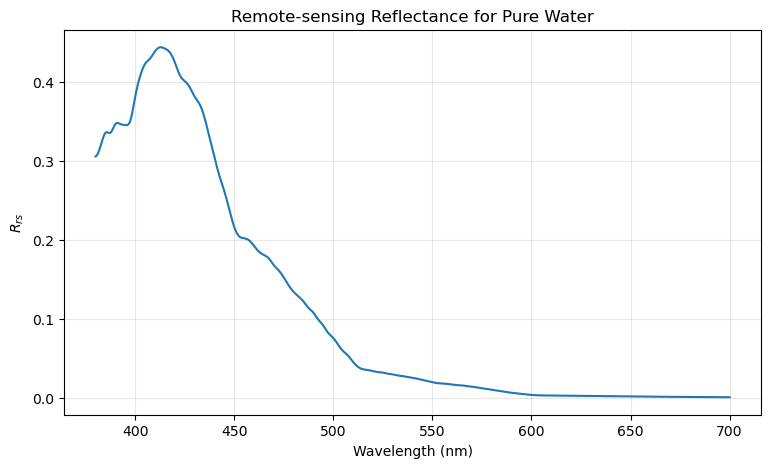

In [6]:
plt.figure(figsize=(9, 5))

# plot the Rrs for water
plt.plot(water_spectrum[:,0], Rrs_water, color=water_color)

plt.xlabel("Wavelength (nm)")
plt.ylabel(r"$R_{rs}$")
plt.title("Remote-sensing Reflectance for Pure Water")
plt.grid(True, alpha=0.3)
plt.show()

Up next, we'll consider how the presence of chlorophyll-a modulates this quantity across the visible spectrum.

## Phytoplankton and Chlorophyll-a

Phytoplankton are drifting photosynthetic organisms that form the base of the marine food web. Nearly all phytoplankton contain **chlorophyll-a**, a pigment used in photosynthesis.

### Absorption by Chlorophyll-a

Chlorophyll-a absorbs strongly in the blue part of the visible spectrum and reflects or scatters more green light. Let's take a look at the spectrum:

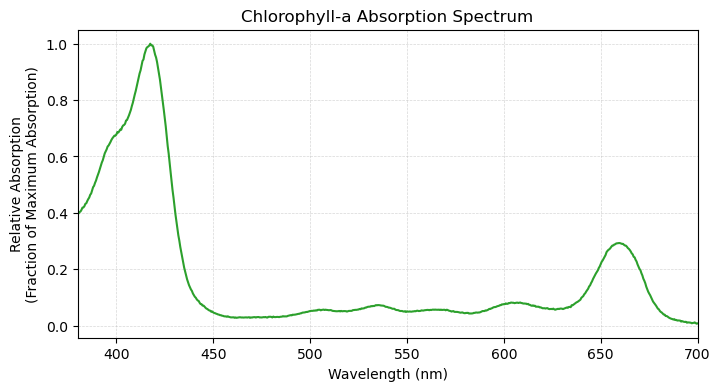

In [7]:
# read in the spectrum
chla_spectrum = np.genfromtxt('../data/ocean_color/chl_absorption_spectrum.csv', delimiter=',')
chla_spectrum[:,1] *= 1/np.max(chla_spectrum[:,1])

# make a plot
fig = plt.figure(figsize=(8,4))
plt.plot(chla_spectrum[:,0], chla_spectrum[:,1], color=chla_color)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Relative Absorption\n(Fraction of Maximum Absorption)')
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)
plt.title('Chlorophyll-a Absorption Spectrum')
plt.gca().set_xlim([380,700])
plt.show()

Here, we can see that there is strong absorption in the 400-450 nm range - the range that absorption by water is low.

### Scattering by Chlorophyll-a

Just like water, chlorophyll-a also scatters light preferentially in the visible spectrum.

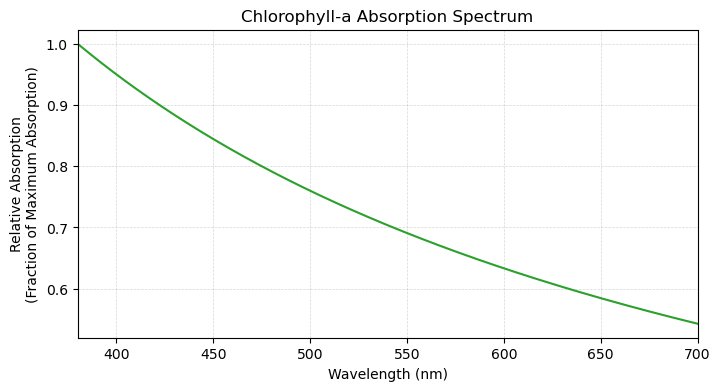

In [8]:
# compute scattering due to chlorophyll
chl_scattering = (550 / wavelength)
chl_scattering *= 1/np.max(chl_scattering)

# make a plot
fig = plt.figure(figsize=(8,4))
plt.plot(chla_spectrum[:,0], chl_scattering, color=chla_color)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Relative Absorption\n(Fraction of Maximum Absorption)')
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)
plt.title('Chlorophyll-a Absorption Spectrum')
plt.gca().set_xlim([380,700])
plt.show()

As we can see , the chlorophyll-a scattering spectrum looks somewhat similar to the water spectrum, but it has an inverse linear dependence on wavelength, rather than an inverse 4th order dependence.

### Remore Sensing Reflectance of Chlorophyll-a in Water

When chlorophyll-a is present in water, the absorbance and scattering properties seen above change the shape of the spectrum of water-leaving radiance. The absorption and scattering are additive but the computation is similar at that for water. Let's bundle this into a function we can use for different chlorophyll-a concentrations. 

In [9]:
def compute_rrs(chl):

    # compute absorption as the sum of water and chlorophyll components
    chl_scale_factor = 0.005
    absorption = water_spectrum[:,1] + chl * chl_scale_factor  * chla_spectrum[:,1]

    # Pure-water-like backscatter
    water_scattering_factor = 5e-5
    water_scattering = water_scattering_factor * (550 / wavelength) ** 4
    # bbw = 5e-5 * (550 / wavelength) ** 4#.3

    # Particle backscatter associated with chlorophyll-a
    chla_scattering_factor = 3e-5 * chl**0.62
    bbp = chla_scattering_factor * (550 / wavelength)

    # Total scattering
    scattering = water_scattering + bbp

    # compute remote sensing reflectance
    Rrs = scattering / (absorption + scattering)
    
    return Rrs

Using this function, let's take a look at how different values for chlorophyll-a modulate the water spectra:

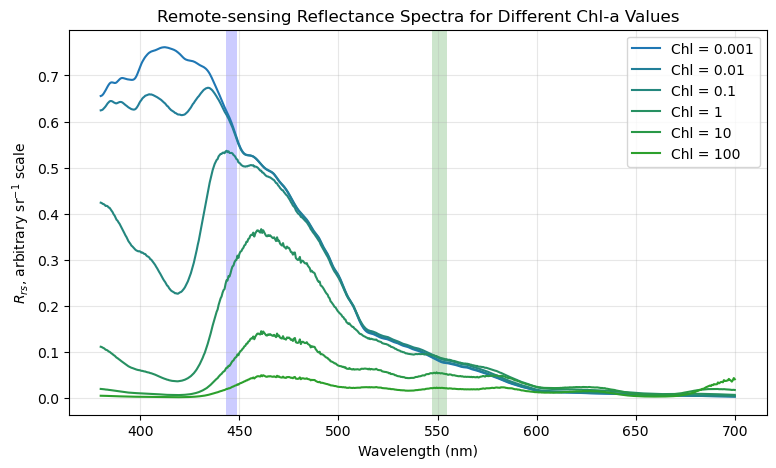

In [10]:
plt.figure(figsize=(9, 5))

chl_values = [0.001, 0.01, 0.1, 1, 10, 100]

for chl in chl_values:
    rrs = compute_rrs(chl)
    color = blue_green_cmap(norm(chl))
    plt.plot(water_spectrum[:,0], rrs, color=color, label=f"Chl = {chl:g}")
y_min, y_max = plt.ylim()
plt.gca().add_patch(Rectangle( (443,y_min), 449-443, y_max-y_min, facecolor='blue', alpha=0.2))
plt.gca().add_patch(Rectangle( (547,y_min), 555-547, y_max-y_min, facecolor='green', alpha=0.2))
plt.xlabel("Wavelength (nm)")
plt.ylabel(r"$R_{rs}$, arbitrary sr$^{-1}$ scale")
plt.title("Remote-sensing Reflectance Spectra for Different Chl-a Values")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


We can see from this plot that the chlorophyll-a concentration increases, the dominant color of water-leaving radiance shifts from blue toward green. This shift is the basis for many empirical satellite chlorophyll-a algorithms.

### Ratios Between Green and Blue Bands

In the above figure, there are two vertical bars in the blue and green parts of the visible spectrum in a typical location where optical satellites are designed to observe. In these locations, we can see that for most chlorophyll-a concentrations, the blue $R_{rs}$ values are higher than green. However, we can compare the the ratio of the values through different values:

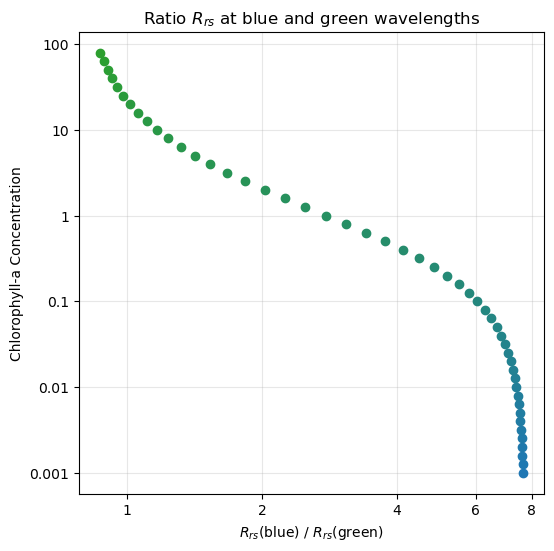

In [12]:
plt.figure(figsize=(6, 6))

# determine indices for the blue and green parts of the spectrum
blue_index = np.argmin(np.abs(water_spectrum[:,0]-443))
green_index = np.argmin(np.abs(water_spectrum[:,0]-550))

# compute chl values
chl_values = 10**np.arange(-3,2,0.1)

# compute and plot Rrs at a range of chl values
for chl in chl_values:
    rrs = compute_rrs(chl)
    color = blue_green_cmap(norm(chl))
    rrs_green = rrs[green_index]
    rrs_blue = rrs[blue_index]
    X = np.log10(rrs_blue/rrs_green)
    plt.plot(X, np.log10(chl), 'o', color=color, label=f"Chl = {chl:g}")

plt.xticks([0,np.log10(2),np.log10(4),np.log10(6),np.log10(8)], [1,2,4,6,8])
plt.xlabel('$R_{rs}$(blue) / $R_{rs}$(green)')
    
plt.yticks([-3, -2, -1, 0, 1, 2], [0.001, 0.01, 0.1, 1, 10, 100])
plt.ylabel('Chlorophyll-a Concentration')
plt.grid(True, alpha=0.3)

plt.title('Ratio $R_{rs}$ at blue and green wavelengths')
plt.show()

As we can see, there is a clear relationship linking satellite-observable properties and the chlorophyll-a concentration - this is the foundation of ocean color algorithms for chlorophyll-a estimates!

## Interpreting Chlorophyll-a Estimates

Chlorophyll-a is one component of sea water absorbtion - but it's not typically the only constitutent in water.

### CDOM and Turbidity

Ocean color is not controlled by chlorophyll-a alone. Two other important constituents are:

- **CDOM:** colored dissolved organic matter, often associated with decaying biological material.
- **Suspended sediments:** particles that increase turbidity and scattering.

CDOM absorption can resemble chlorophyll-a absorption in the blue part of the spectrum, but CDOM lacks the additional chlorophyll-a absorption feature near 680 nm. This makes spectral information important for separating different water-column constituents.

In [ ]:
chl_abs = 1.2*np.exp(-0.5*((wl-440)/35)**2) + 0.55*np.exp(-0.5*((wl-675)/18)**2)
cdom_abs = np.exp(-0.018*(wl-400))
chl_abs = chl_abs / chl_abs.max()
cdom_abs = cdom_abs / cdom_abs.max()

plt.figure(figsize=(8,4))
plt.plot(wl, chl_abs, label='Chlorophyll-a absorption')
plt.plot(wl, cdom_abs, label='CDOM absorption')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Relative absorption')
plt.title('Conceptual Absorption by Chlorophyll-a and CDOM')
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend()
plt.show()

### Gross and Net Primary Productivity

Chlorophyll-a not the same thing as primary productivity. Chlorophyll-a gives information about phytoplankton biomass or pigment concentration, while productivity describes rates of carbon fixation.

For example, two regions may have similar chlorophyll-a concentrations but different productivity if light, nutrients, temperature, or grazing rates differ. Zooplankton grazing can also remove phytoplankton as quickly as they grow, masking changes in production when looking only at chlorophyll-a.

- **Gross Primary Productivity (GPP):** total rate of organic carbon production through photosynthesis.
- **Respiration:** conversion of organic carbon back to inorganic carbon by autotrophs and other organisms.
- **Net Primary Productivity (NPP):** net rate of carbon fixation after accounting for autotrophic respiration.

Ocean color products can help estimate productivity, but chlorophyll-a alone is not enough. Productivity algorithms usually require additional information such as light availability, temperature, mixed-layer depth, and assumptions about phytoplankton physiology.

In [ ]:
# Conceptual productivity example
chl = np.linspace(0.05, 5, 100)
par_low = 20
par_high = 50

# A simple saturating productivity index for teaching
prod_low_light = chl * (1 - np.exp(-par_low/35))
prod_high_light = chl * (1 - np.exp(-par_high/35))

plt.figure(figsize=(8,4))
plt.plot(chl, prod_low_light, label='Lower PAR')
plt.plot(chl, prod_high_light, label='Higher PAR')
plt.xlabel('Chlorophyll-a (mg m$^{-3}$)')
plt.ylabel('Conceptual productivity index')
plt.title('Same Chlorophyll-a Can Imply Different Productivity Under Different Light')
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend()
plt.show()

**Key Takeaways**

Ocean color remote sensing connects physics, biology, and data processing:

1. Sunlight enters the ocean and interacts with water, phytoplankton, CDOM, and suspended particles.
2. A small fraction of light exits the ocean as water-leaving radiance.
6. Chlorophyll-a is useful, but it should not be interpreted as a direct measurement of primary productivity.

**Additional Information**
Log this more appropriately later
- https://www.oceanopticsbook.info/view/atmospheric-correction/normalized-reflectances
- https://opg.optica.org/oe/fulltext.cfm?uri=oe-25-12-A564